##  Supply Chain Shipment Pricing - Key Perfomance Indicators (KPI) Analysis

In [1]:
# Import Libraries 

import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as ticker
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [2]:
# Connect Database 

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print ( ' Database Connection is done. ')
#  os.makedirs("outputs", exist_ok=True)
sns.set_style("whitegrid")
 

 Database Connection is done. 


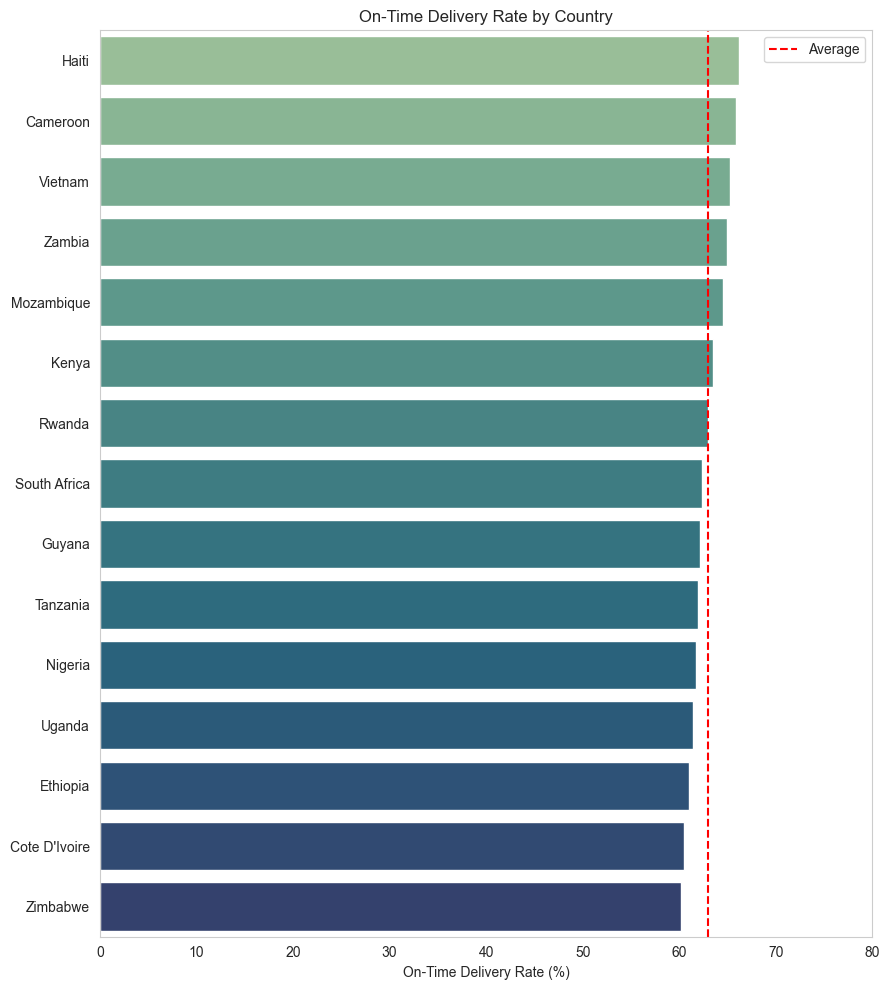

In [3]:
# On-Time Delivery Rate by Country

otd_country = pd.read_sql("SELECT * FROM vw_otd_by_country;", engine)
# otd_country = otd_country[otd_country["total_shipments"] >= 50]  

plt.figure(figsize=(9, 10))
sns.barplot( data=otd_country.sort_values("on_time_delivery_rate_pct", ascending = False), 
              x="on_time_delivery_rate_pct", y="country", hue='country', palette = 'crest' ,legend = False
            )
plt.axvline(otd_country["on_time_delivery_rate_pct"].mean(), color="red", linestyle="--", label="Average")
plt.title("On-Time Delivery Rate by Country")
plt.xlabel("On-Time Delivery Rate (%)")
plt.ylabel("")
plt.xlim(right=80)
plt.legend(loc="upper right")
plt.tight_layout()
plt.grid(False)
plt.savefig("otd_by_country.png", dpi=120)
plt.show()
plt.close()

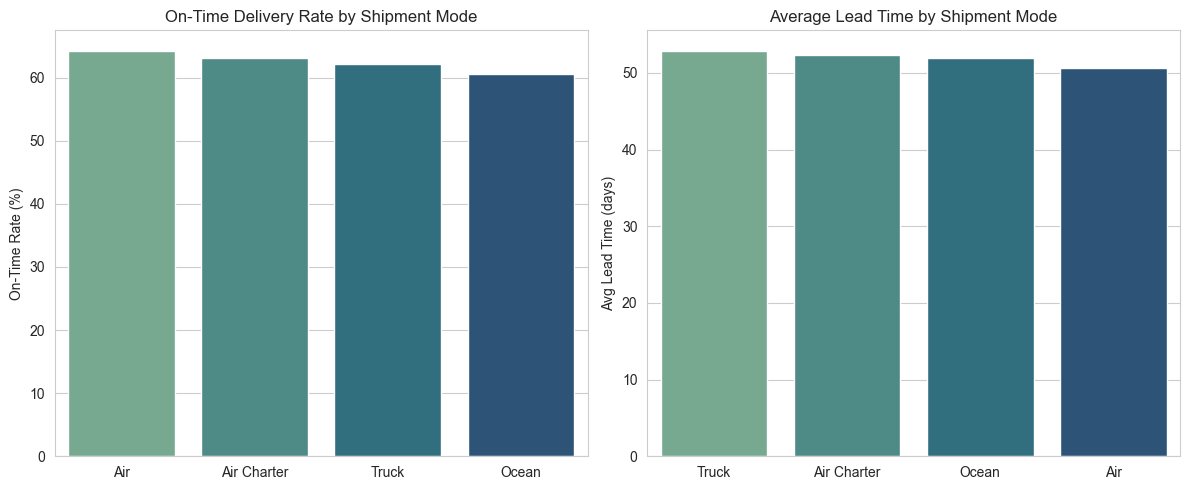

In [4]:
# On-Time Delivery Rate & Lead Time by Shipment Mode

otd_shipment_mode = pd.read_sql("SELECT * FROM vw_otd_by_shipment_mode;", engine)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=otd_shipment_mode.sort_values(by = 'on_time_delivery_rate_pct', ascending = False), x="shipment_mode", y="on_time_delivery_rate_pct", 
            hue = 'shipment_mode', ax=axes[0], palette='crest')
axes[0].set_title("On-Time Delivery Rate by Shipment Mode")
axes[0].set_ylabel("On-Time Rate (%)")
axes[0].set_xlabel("")

sns.barplot(data=otd_shipment_mode.sort_values(by = 'avg_lead_time_days', ascending = False), x="shipment_mode", y="avg_lead_time_days", 
            hue = 'shipment_mode', ax=axes[1], palette = 'crest')
axes[1].set_title("Average Lead Time by Shipment Mode")
axes[1].set_ylabel("Avg Lead Time (days)")
axes[1].set_xlabel("")
plt.tight_layout()
plt.savefig("otd_and_leadtime_by_shipment_mode.png", dpi=120)
plt.show()
plt.close()

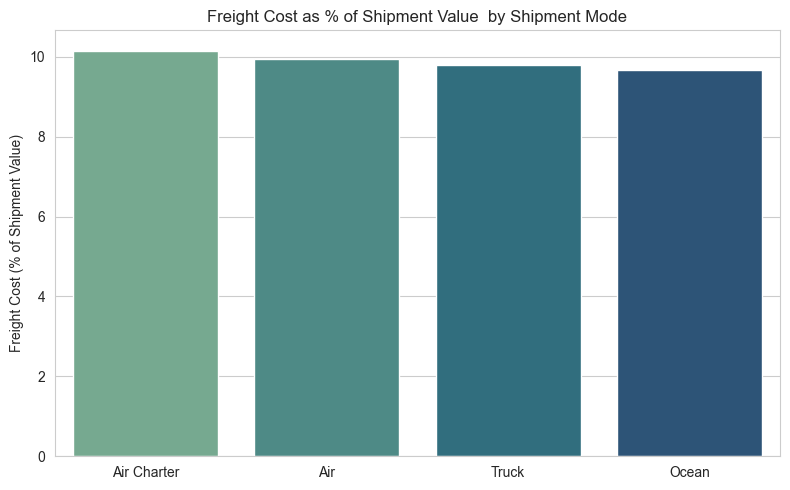

In [5]:
# Freight Cost Efficiency by Shipment Mode

freight_shipment_mode = pd.read_sql("SELECT * FROM vw_freight_efficiency_by_mode;", engine)

plt.figure(figsize=(8, 5))
sns.barplot(data=freight_shipment_mode.sort_values(by = 'avg_freight_pct_of_value', ascending = False), x="shipment_mode", y="avg_freight_pct_of_value", 
            hue = 'shipment_mode', palette='crest')
plt.title("Freight Cost as % of Shipment Value  by Shipment Mode")
plt.ylabel("Freight Cost (% of Shipment Value)")
plt.xlabel("")
plt.tight_layout()
plt.savefig("freight_pct_by_shipment_mode.png", dpi=120)
plt.show()
plt.close()

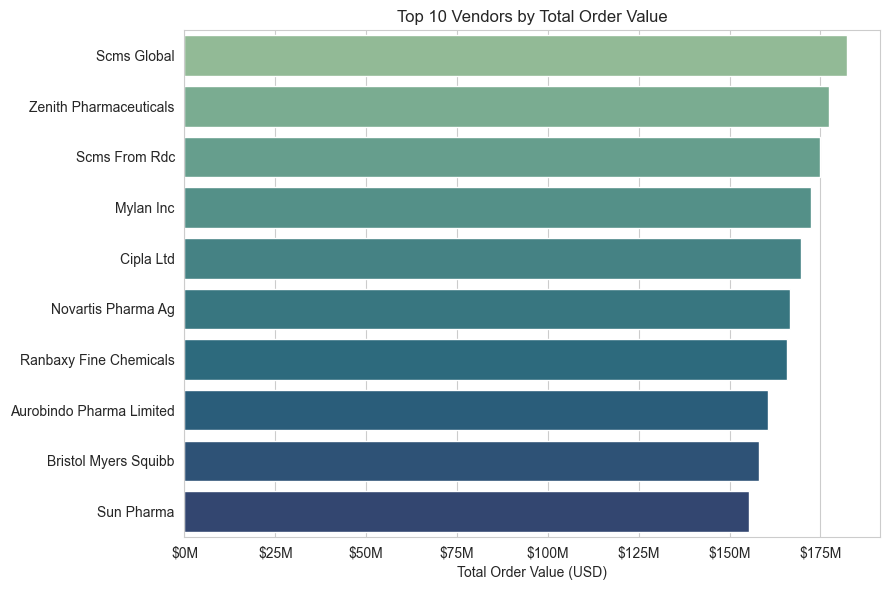

In [6]:
# Top 10 Vendors by Spend 

vendors = pd.read_sql("SELECT * FROM vw_vendor_scorecard;", engine).head(10)

plt.figure(figsize=(9, 6))
sns.barplot( data=vendors.sort_values("total_order_value_usd" , ascending = False), y="vendor", x="total_order_value_usd", hue = 'vendor', palette = 'crest')
plt.title("Top 10 Vendors by Total Order Value")
plt.xlabel("Total Order Value (USD)")
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x*1e-6:,.0f}M"))
plt.ylabel("")
plt.tight_layout()
plt.savefig("top_vendors_by_spend.png", dpi=120)
plt.show()
plt.close()


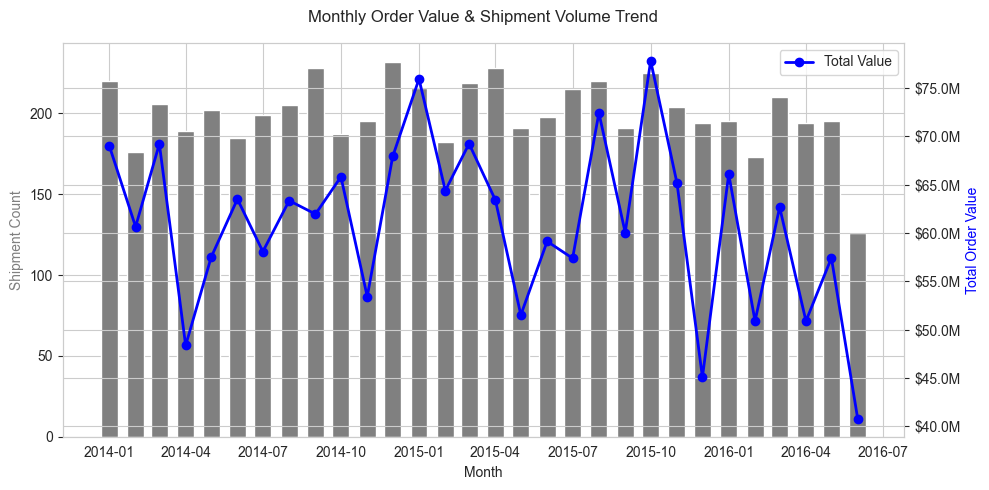

In [7]:
# Monthly Spend & Shipment Volume Trend

monthly_trend = pd.read_sql("SELECT * FROM vw_monthly_trend;", engine)
monthly_trend["order_month"] = pd.to_datetime(monthly_trend["order_month"])

fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary Axis: Bars for Shipment Count
ax1.bar(monthly_trend["order_month"], monthly_trend["shipment_count"], color="gray", width=20, label="Shipment Count")
ax1.set_ylabel("Shipment Count", color="gray")
ax1.set_xlabel("Month")

# Secondary Axis: Line for Order Value
ax2 = ax1.twinx()
ax2.plot(monthly_trend["order_month"], monthly_trend["total_value_usd"], color="blue", marker="o", linewidth=2, label="Total Value")
ax2.set_ylabel("Total Order Value", color="blue" )
# Format secondary Y-axis in Millions ($M)
ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x*1e-6:.1f}M")
)

plt.title("Monthly Order Value & Shipment Volume Trend", pad=15)
plt.legend()
fig.tight_layout()
plt.savefig("monthly_trend.png", dpi=120)
plt.show()
plt.close()


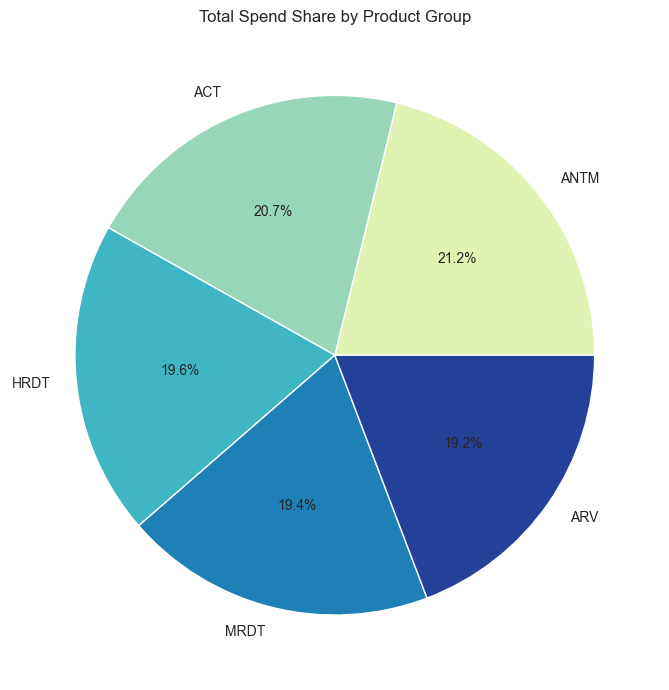

In [8]:
spend = pd.read_sql("""
                    SELECT product_group, SUM(total_spend) AS total_spend
                    FROM vw_spend_by_product_country
                    GROUP BY product_group
                    ORDER BY total_spend DESC;
                    """, engine)

plt.figure(figsize=(7, 7))
plt.pie(spend["total_spend"], labels=spend["product_group"], autopct="%1.1f%%", colors=sns.color_palette('YlGnBu', len(spend)))
plt.title("Total Spend Share by Product Group")
plt.tight_layout()
plt.savefig("spend_by_product_group.png", dpi=120)
plt.show()
plt.close()

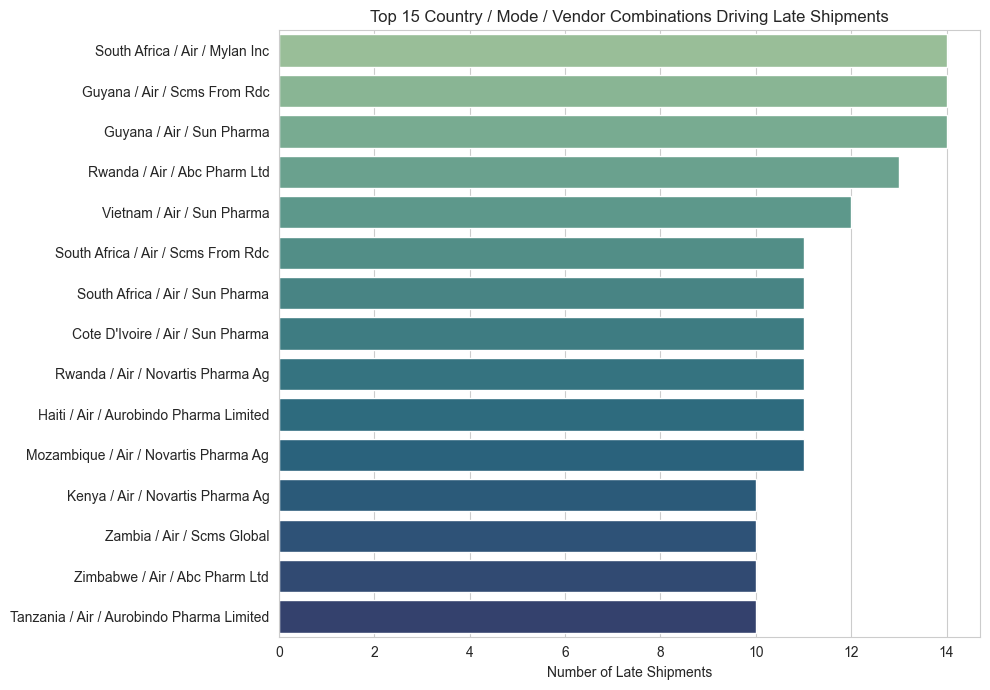

In [9]:
 # Late Shipment Root Cause — top country / mode / vendor 
# Usecase : Operations teams need to see exactly where delays occurs , not just the overall on-time rate.

late_drivers = pd.read_sql("SELECT * FROM vw_late_shipment_drivers;", engine)
late_drivers["combo_label"] = (
                               late_drivers["country"] + " / " + late_drivers["shipment_mode"] + " / " + late_drivers["vendor"]
                               )

plt.figure(figsize=(10, 7))
sns.barplot( data = late_drivers.sort_values("late_shipments", ascending = False).head(15),x="late_shipments", y="combo_label",hue = "combo_label",  palette = 'crest')
plt.title("Top 15 Country / Mode / Vendor Combinations Driving Late Shipments")
plt.xlabel("Number of Late Shipments")
plt.ylabel("")
plt.tight_layout()
plt.savefig("late_shipment_drivers.png", dpi=120)
plt.show()
plt.close()

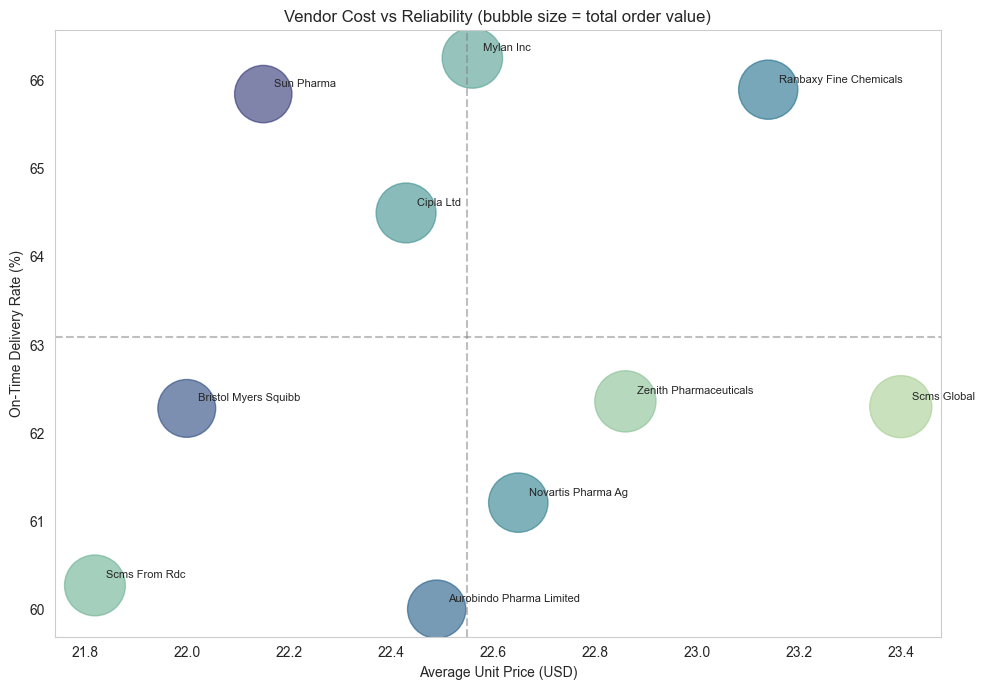

In [10]:
# Vendor Cost vs Reliability Trade-off
# Use Case: 
# Which vendors are cheap but unreliable, and which justify a premium?
#  Bubble size = total order value, so the biggest-spend vendors stand out.
#   Top-Left Quadrant: Best Value (Low Cost, High Reliability)
#   Top-Right Quadrant: Premium Vendors (High Cost, High Reliability)
#   Bottom-Left Quadrant: Budget / Low Performance (Low Cost, Low Reliability)
#   Bottom-Right Quadrant: Highest Risk (High Cost, Low Reliability)

plt.figure(figsize=(10, 7))
plt.scatter(vendors["avg_unit_price"], vendors["on_time_delivery_rate_pct"],
                      s=vendors["total_order_value_usd"] / vendors["total_order_value_usd"].max() * 2000,
                      alpha=0.6, c=range(len(vendors)), cmap="crest"
                    )
for _, row in vendors.iterrows():
    plt.annotate(row["vendor"], (row["avg_unit_price"], row["on_time_delivery_rate_pct"]),
                 fontsize=8, xytext=(8, 5), textcoords="offset points")
plt.axhline(vendors["on_time_delivery_rate_pct"].mean(), color="gray", linestyle="--", alpha=0.5)
plt.axvline(vendors["avg_unit_price"].mean(), color="gray", linestyle="--", alpha=0.5)
plt.title("Vendor Cost vs Reliability (bubble size = total order value)")
plt.xlabel("Average Unit Price (USD)")
plt.ylabel("On-Time Delivery Rate (%)")
plt.grid(False)
plt.tight_layout()
plt.savefig("vendor_cost_vs_reliability.png", dpi=120)
plt.show()
plt.close()

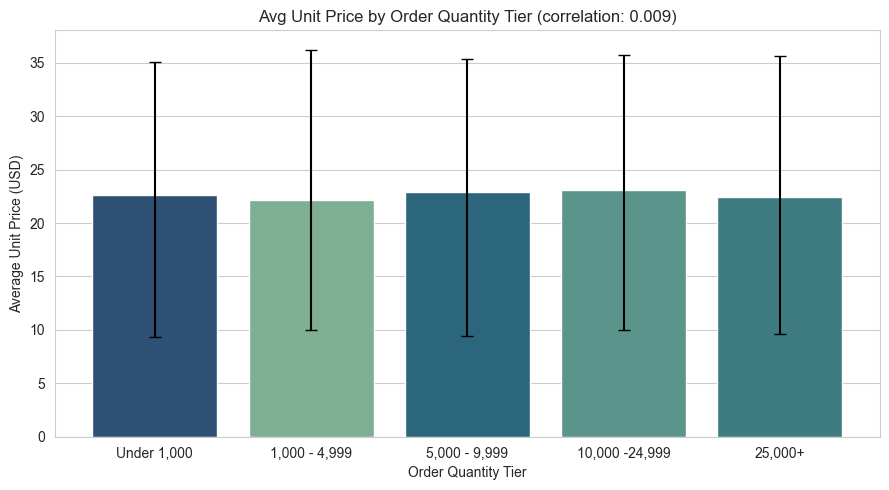

In [11]:
# Order Quantity vs Unit Price (bulk discount check)
# Use Case:
# Does ordering more actually earn a better price?
#        ---  <-- Top Cap (+1 Standard Deviation)
#         |
#         |   <-- Length set by yerr (unit_price_stddev)
#         |
#       ( y ) <-- Center point set by avg_unit_price
#         |
#         |
#        ---  <-- Bottom Cap (-1 Standard Deviation)

qty_price = pd.read_sql("SELECT * FROM vw_quantity_vs_price;", engine)

correlation = pd.read_sql("""
                            SELECT ROUND(CORR(line_item_quantity, unit_price)::NUMERIC, 3) AS corr
                            FROM clean_shipment_pricing
                            WHERE line_item_quantity IS NOT NULL AND unit_price IS NOT NULL;
                          """, engine
                        )["corr"][0]
tier_order = [
    "Under 1,000",
    "1,000 - 4,999",
    "5,000 - 9,999",
    "10,000 -24,999",
    "25,000+",
]

plt.figure(figsize=(9, 5))
sns.barplot(data=qty_price, x="quantity_tier", y="avg_unit_price",order = tier_order, hue = 'quantity_tier', palette = 'crest')
plt.errorbar(x=range(len(qty_price)), y=qty_price["avg_unit_price"],
             yerr=qty_price["unit_price_stddev"], fmt="none", color="black", capsize=4)
plt.title(f"Avg Unit Price by Order Quantity Tier (correlation: {correlation})")
plt.xlabel("Order Quantity Tier")
plt.ylabel("Average Unit Price (USD)")
# plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("quantity_vs_price.png", dpi=120)
plt.show()
plt.close()

## KPI Analysis - Summary

In [12]:


print("KPI SUMMARY : ")
query = """
SELECT ROUND(100.0 * SUM(CASE WHEN is_on_time = 'YES' THEN 1 ELSE 0 END) / COUNT(is_on_time), 2) AS r 
FROM clean_shipment_pricing;
"""
otd_rate = pd.read_sql(query, engine)['r'][0]

best_otd = otd_country.sort_values('on_time_delivery_rate_pct', ascending=False).iloc[0]['country']
worst_otd = otd_country.sort_values('on_time_delivery_rate_pct').iloc[0]['country']
cheapest_mode = freight_shipment_mode.sort_values('avg_freight_pct_of_value').iloc[0]['shipment_mode']

top_vendor = vendors.iloc[0]['vendor'] if len(vendors) else 'N/A'

top_driver_row = late_drivers.sort_values('late_shipments', ascending=False).iloc[0]
top_driver_label = top_driver_row['combo_label']
top_driver_count = top_driver_row['late_shipments']


print(f"Overall on-time delivery rate: {otd_rate} %")
print(f"Best OTD country: {best_otd}")
print(f"Worst OTD country: {worst_otd}")
print(f"Cheapest freight mode (% of value): {cheapest_mode}")
print(f"Top vendor by spend: {top_vendor}")
print(f"Top late-shipment driver: {top_driver_label} ({top_driver_count} late shipments)")
print(f"Quantity-to-price correlation: {correlation:.3f}")
    



KPI SUMMARY : 
Overall on-time delivery rate: 63.02 %
Best OTD country: Haiti
Worst OTD country: Zimbabwe
Cheapest freight mode (% of value): Ocean
Top vendor by spend: Scms Global
Top late-shipment driver: South Africa / Air / Mylan Inc (14 late shipments)
Quantity-to-price correlation: 0.009
